<a href="https://colab.research.google.com/github/biglalo104/Projects/blob/main/Two%20different%20clustering%20methods%20clustering%20to%20group%20Kenyan%20regions%20based%20on%20soil%20and%20rainfall%20characteristics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pyspark pandas numpy     # Java 8/11/17 required

In [4]:
import pandas as pd
import io

data = """County,Rainfall_mm,Rainy_days,Soil_pH,Org_carbon_pct,Clay_pct
Kericho,1600,160,4.8,3.5,40
Kisii,1700,170,5.0,3.2,45
Kakamega,1800,180,5.0,2.8,35
Murang'a,1400,140,5.2,3.0,40
Nyandarua,1200,130,5.5,3.0,30
Meru,1300,140,5.3,2.9,35
Trans Nzoia,1100,120,5.8,2.5,45
Uasin Gishu,1000,110,6.0,2.2,45
Nakuru,900,100,6.2,2.0,35
Bungoma,1400,150,5.5,2.4,40
Siaya,1300,140,5.7,2.0,35
Machakos,700,75,6.5,1.1,30
Kitui,600,65,6.8,0.9,30
Kajiado,550,60,7.5,0.8,25
Baringo,700,70,7.2,0.9,35
Laikipia,650,70,6.9,1.0,30
Kilifi,1000,110,6.5,1.2,15
Turkana,250,30,8.2,0.4,25
Marsabit,300,35,8.0,0.5,20
Wajir,280,30,8.3,0.4,30
Garissa,300,35,8.1,0.5,35
Mandera,260,28,8.4,0.4,30
Isiolo,350,40,7.8,0.6,28
Samburu,400,45,7.6,0.7,26"""

df = pd.read_csv(io.StringIO(data))
print(df.head())

      County  Rainfall_mm  Rainy_days  Soil_pH  Org_carbon_pct  Clay_pct
0    Kericho         1600         160      4.8             3.5        40
1      Kisii         1700         170      5.0             3.2        45
2   Kakamega         1800         180      5.0             2.8        35
3   Murang'a         1400         140      5.2             3.0        40
4  Nyandarua         1200         130      5.5             3.0        30


In [6]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = SparkSession.builder.master("local[*]").appName("Kenya_Soil_Rain").getOrCreate()

# The CSV data that was previously loaded into a pandas DataFrame is now explicitly included here
# as a string to create a PySpark DataFrame, addressing the 'file not found' error.
data_string = """County,Rainfall_mm,Rainy_days,Soil_pH,Org_carbon_pct,Clay_pct
Kericho,1600,160,4.8,3.5,40
Kisii,1700,170,5.0,3.2,45
Kakamega,1800,180,5.0,2.8,35
Murang'a,1400,140,5.2,3.0,40
Nyandarua,1200,130,5.5,3.0,30
Meru,1300,140,5.3,2.9,35
Trans Nzoia,1100,120,5.8,2.5,45
Uasin Gishu,1000,110,6.0,2.2,45
Nakuru,900,100,6.2,2.0,35
Bungoma,1400,150,5.5,2.4,40
Siaya,1300,140,5.7,2.0,35
Machakos,700,75,6.5,1.1,30
Kitui,600,65,6.8,0.9,30
Kajiado,550,60,7.5,0.8,25
Baringo,700,70,7.2,0.9,35
Laikipia,650,70,6.9,1.0,30
Kilifi,1000,110,6.5,1.2,15
Turkana,250,30,8.2,0.4,25
Marsabit,300,35,8.0,0.5,20
Wajir,280,30,8.3,0.4,30
Garissa,300,35,8.1,0.5,35
Mandera,260,28,8.4,0.4,30
Isiolo,350,40,7.8,0.6,28
Samburu,400,45,7.6,0.7,26"""

# Create a PySpark DataFrame from the multiline string
df = spark.read.option("header", True).option("inferSchema", True).csv(
    spark.sparkContext.parallelize(data_string.splitlines())
)

FEATS = ["Rainfall_mm","Rainy_days","Soil_pH","Org_carbon_pct","Clay_pct"]
# Impute missing values with the mean for each feature column
df = df.na.fill({c: df.agg(F.mean(c)).first()[0] for c in FEATS})   # impute missing

df_f = VectorAssembler(inputCols=FEATS, outputCol="features").transform(df)
data = StandardScaler(inputCol="features", outputCol="scaled") \
       .fit(df_f).transform(df_f)          # standardize: mm vs % vs pH have different scales

In [7]:
ev = ClusteringEvaluator(featuresCol="scaled", metricName="silhouette")
for k in (2,3,4,5,6):
    m = KMeans(k=k, seed=42, featuresCol="scaled").fit(data)
    print(k, round(ev.evaluate(m.transform(data)),3))     # k=3 typically wins

km = KMeans(k=3, seed=42, featuresCol="scaled").fit(data)

2 0.809
3 0.612
4 0.565
5 0.5
6 0.456


In [8]:
bkm = BisectingKMeans(k=3, seed=42, featuresCol="scaled").fit(data)

for name, mdl in [("KMeans",km), ("BisectingKMeans",bkm)]:
    r = mdl.transform(data)
    print(name, "silhouette:", round(ev.evaluate(r),3))
    r.groupBy("prediction").agg(F.count("*").alias("n"),
        *[F.round(F.mean(c),1).alias(c) for c in FEATS],
        F.collect_list("County").alias("counties")) \
     .orderBy("prediction").show(truncate=False)

# agreement between the two methods
a = km.transform(data).select("County", F.col("prediction").alias("K"))
b = bkm.transform(data).select("County", F.col("prediction").alias("B"))
a.join(b,"County").groupBy("K","B").count().show()   # high agreement => robust groups

KMeans silhouette: 0.612
+----------+---+-----------+----------+-------+--------------+--------+------------------------------------------------------------------------------------------------------------------+
|prediction|n  |Rainfall_mm|Rainy_days|Soil_pH|Org_carbon_pct|Clay_pct|counties                                                                                                          |
+----------+---+-----------+----------+-------+--------------+--------+------------------------------------------------------------------------------------------------------------------+
|0         |13 |487.7      |53.3      |7.5    |0.7           |27.6    |[Machakos, Kitui, Kajiado, Baringo, Laikipia, Kilifi, Turkana, Marsabit, Wajir, Garissa, Mandera, Isiolo, Samburu]|
|1         |3  |1700.0     |170.0     |4.9    |3.2           |40.0    |[Kericho, Kisii, Kakamega]                                                                                        |
|2         |8  |1200.0     |128.8     |5

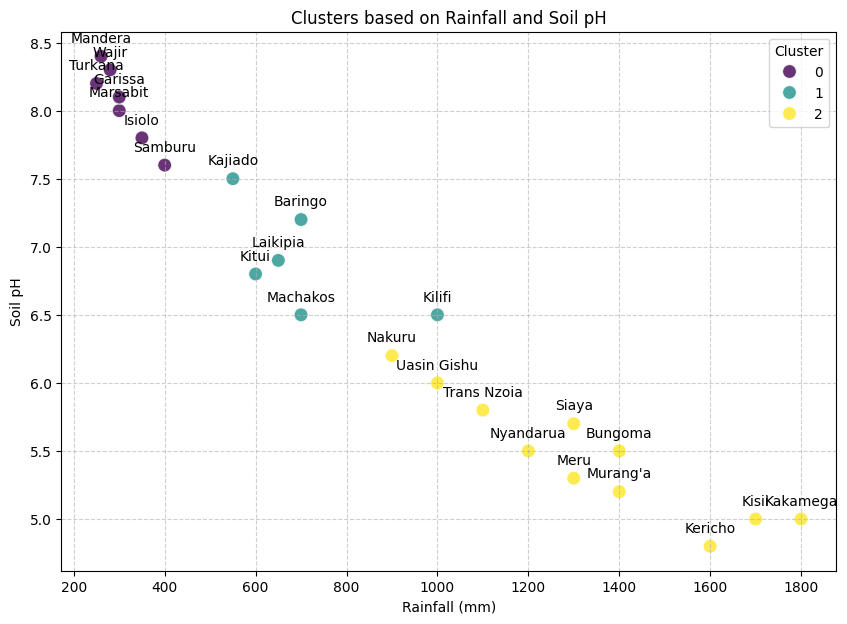

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the PySpark DataFrame 'r' (from the last clustering model) to a Pandas DataFrame for plotting
clusters_pd = r.select("County", "Rainfall_mm", "Soil_pH", "prediction").toPandas()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=clusters_pd,
    x="Rainfall_mm",
    y="Soil_pH",
    hue="prediction",
    palette="viridis",
    s=100, # size of points
    alpha=0.8
)

# Add county names as annotations
for i, row in clusters_pd.iterrows():
    plt.annotate(row['County'], (row['Rainfall_mm'], row['Soil_pH']), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Clusters based on Rainfall and Soil pH')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Soil pH')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()